In [1]:
#LOAD DATA AND PREPROCESSING
import pandas as pd
import numpy as np
import ast

# === STEP 1: LOAD & RENAME ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)

# === STEP 2: SUBSET AND CLEAN ===
selected_columns = df[[
    'node', '_wkshell', 'Y2H_wkshell',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'DeepTMHMM_class', 'signalP_trimmed_sequence',
    'IDR_count', 'N_aa_disordered', 'disorder_fraction',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00',
    'mean_plddt', 'L', 
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy',
    'Christiano_degradation_rate(min-1)', 'Villen_halflife_min',
    'mean_molecules_per_cell', 'median_molecules_per_cell', 'log2_TE',
    'interacting_chaperones', 'in_complex', 'Pfam_Ndomains', 
    'essential',  
    'sequence', 'structure_exists', 'sequence_matches_structure', 'meltome-melting-point', 'meltome-AUC', 'meltome-fit-R2'
       
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chpaerone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = selected_columns[selected_columns["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
selected_columns = selected_columns[selected_columns["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {selected_columns.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
selected_columns = selected_columns[selected_columns["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {selected_columns.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 82 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   Y2H_wkshell                            1465 non-null   float64
 3   MS_degree_centrality                   3927 non-null   float64
 4   MS_betweenness_centrality              3927 non-null   float64
 5   MS_eigenvector_centrality              3927 non-null   float64
 6   MS_closeness_centrality                3927 non-null   float64
 7   MS_load_centrality                     3927 non-null   float64
 8   MS_pagerank                            3927 non-null   float64
 9   MS_information_centrality              3927 non-null   float64
 10  Y2H_degree_centrality                  1465 non-null   float64
 11  Y2H_

In [2]:
# Filter: Remove low pLDDT and TMD/SP proteins
filtered_df = selected_columns[
    (selected_columns['mean_plddt'] >= 50) &
    (~selected_columns['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()
# Optional: Print stats to verify
print(f"Original rows: {len(selected_columns)}")
print(f"Filtered rows: {len(filtered_df)}")

# Update selected_columns to use the filtered version for downstream codes
selected_columns = filtered_df

Original rows: 3859
Filtered rows: 3209


In [3]:
# SCRIPT 2: Feature & Target Preparation
import pandas as pd
import numpy as np

# Filter nodes to those where sequence matches structure
selected_columns = selected_columns[
    selected_columns['sequence_matches_structure'] == True
].copy()

# 1. Create binary target for top 10% MS_degree_centrality
threshold = selected_columns['MS_degree_centrality'].quantile(0.90)  # top 10% cutoff
selected_columns['y_top10'] = (
    selected_columns['MS_degree_centrality'] >= threshold
).astype(int)

# 2. Feature & Target Preparation
ml_features = [
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score',
    'Villen_halflife_min',
    'mean_molecules_per_cell',
    'interacts_with_chaperone', 'in_complex',
    'essential',
    'meltome-melting-point', 'N_aa_disordered', 'disorder_fraction', 'mean_plddt'
]

X = selected_columns[ml_features].copy()
y = selected_columns['y_top10'].copy()

# Replace common string indicators of missing values with NaN, then convert to numeric
missing_indicators = [
    'n.d.', 'N.D.', 'nd', 'ND', 'na', 'NA', 'null', 'NULL',
    'missing', 'MISSING', '-', 'n/a', 'N/A', ''
]

for col in ml_features:
    X[col] = X[col].replace(missing_indicators, np.nan)
    X[col] = pd.to_numeric(X[col], errors='coerce')

# --- Optional: Create missingness indicators ---
# missing_features = [col for col in X.columns if X[col].isnull().any()]
# for col in missing_features:
#     X[f"{col}_missing"] = X[col].isnull().astype(int)
# missing_indicator_features = [f"{col}_missing" for col in missing_features]
# ml_features_extended = ml_features + missing_indicator_features

# Fill remaining NaNs with -999 (important for sklearn RF)
X_filled = X.fillna(-999)

print("✅ Data preparation complete")
print(f"Total usable samples: {len(X_filled)}")

✅ Data preparation complete
Total usable samples: 3209


Data split completed:
Training samples: 2567
Test samples: 642
Training class ratio (High PME): 10.1%
Random Forest model trained.

Model Performance:
Balanced Accuracy: 0.763
Precision: 0.632
Recall: 0.562
F1 Score: 0.595
ROC-AUC: 0.913

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       578
           1       0.63      0.56      0.60        64

    accuracy                           0.92       642
   macro avg       0.79      0.76      0.78       642
weighted avg       0.92      0.92      0.92       642

Confusion Matrix:
TP: 36, FP: 21, TN: 557, FN: 28
True Positive Rate: 0.562
False Positive Rate: 0.036

Computing SHAP values...


/tmp/ipykernel_500740/684391649.py:95: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


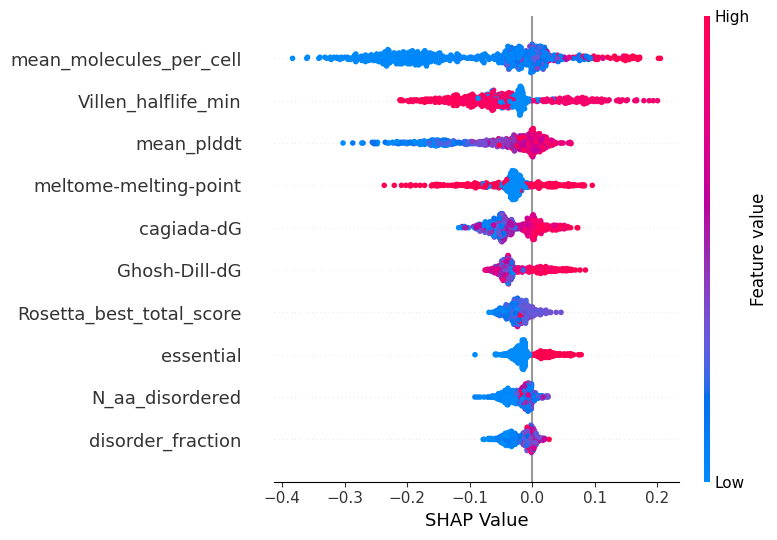


Random Forest Gini-based Feature Importances:
                 Feature  Gini Importance
 mean_molecules_per_cell         0.232842
     Villen_halflife_min         0.157572
              mean_plddt         0.111268
           Ghosh-Dill-dG         0.092303
   meltome-melting-point         0.091168
              cagiada-dG         0.076324
Rosetta_best_total_score         0.066166
         N_aa_disordered         0.054585
       disorder_fraction         0.052861
               essential         0.027646
interacts_with_chaperone         0.018882
              in_complex         0.018382

Generating ROC data...
ROC Data Summary:
Points: 87
AUC Score: 0.913279

Complete ROC Data (Copy/Paste for Origin):
# False_Positive_Rate	True_Positive_Rate	Threshold	Specificity	Sensitivity	Point_Index	Youden_J	Distance_to_Perfect
0.00000000	0.00000000	inf	1.00000000	0.00000000	0.0	0.00000000	1.00000000
0.00000000	0.01562500	0.94603344	1.00000000	0.01562500	1.0	0.01562500	0.98437500
0.00000000	0.250000

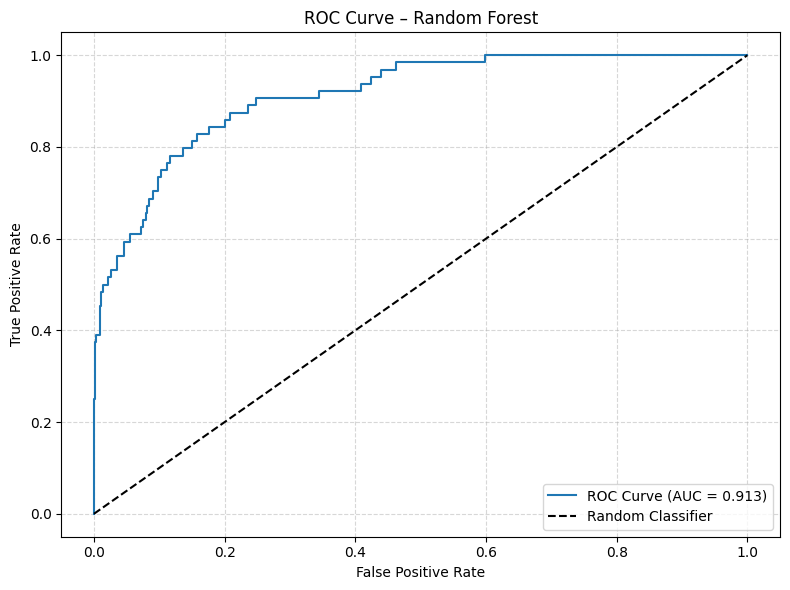

In [4]:
# SCRIPT 1: Basic Random Forest (no hyperparameter tuning)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# Set reproducibility seed
np.random.seed(42)

# -------------------------------------------
# 1. Train-Test Split
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Data split completed:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Training class ratio (High PME): {np.mean(y_train)*100:.1f}%")

# -------------------------------------------
# 2. Random Forest Model Training
# -------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Random Forest model trained.")

# -------------------------------------------
# 3. Evaluation
# -------------------------------------------
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

bal_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nModel Performance:")
print(f"Balanced Accuracy: {bal_accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"True Positive Rate: {tp/(tp+fn):.3f}")
print(f"False Positive Rate: {fp/(fp+tn):.3f}")

# -------------------------------------------
# 4. SHAP Feature Importance
# -------------------------------------------
print("\nComputing SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Handle output shape depending on SHAP version
if isinstance(shap_values, list):
    shap_class_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_class_values = shap_values[:, :, 1]
else:
    shap_class_values = shap_values

feature_names_list = list(X_filled.columns)

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_class_values,
    X_test,
    feature_names=feature_names_list,
    plot_type='dot',
    max_display=10,
    show=False
)
plt.xlabel('SHAP Value')
plt.tight_layout()
plt.savefig('SHAP_random_forest1.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------
# 5. Gini Feature Importances
# -------------------------------------------
print("\nRandom Forest Gini-based Feature Importances:")
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names_list,
    'Gini Importance': importances
}).sort_values(by='Gini Importance', ascending=False)

print(importance_df.to_string(index=False))

# -------------------------------------------
# 6. Generate ROC Data Table for Origin
# -------------------------------------------
print("\nGenerating ROC data...")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Threshold': thresholds,
    'Specificity': 1 - fpr,
    'Sensitivity': tpr,
    'Point_Index': range(len(fpr))
})

roc_df['Youden_J'] = roc_df['Sensitivity'] + roc_df['Specificity'] - 1
roc_df['Distance_to_Perfect'] = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)

print("ROC Data Summary:")
print(f"Points: {len(roc_df)}")
print(f"AUC Score: {roc_auc:.6f}")

print("\nComplete ROC Data (Copy/Paste for Origin):")
print("# False_Positive_Rate\tTrue_Positive_Rate\tThreshold\tSpecificity\tSensitivity\tPoint_Index\tYouden_J\tDistance_to_Perfect")

for idx, row in roc_df.iterrows():
    print(f"{row['False_Positive_Rate']:.8f}\t{row['True_Positive_Rate']:.8f}\t{row['Threshold']:.8f}\t"
          f"{row['Specificity']:.8f}\t{row['Sensitivity']:.8f}\t{row['Point_Index']}\t"
          f"{row['Youden_J']:.8f}\t{row['Distance_to_Perfect']:.8f}")

# -------------------------------------------
# 7. Plot ROC Curve
# -------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(roc_df['False_Positive_Rate'], roc_df['True_Positive_Rate'], label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
